Shape: (284807, 31)
Missing values: 0

Non-fraud: 284,315 (99.8273%)
Fraud:     492 (0.1727%)
Ratio:     578:1


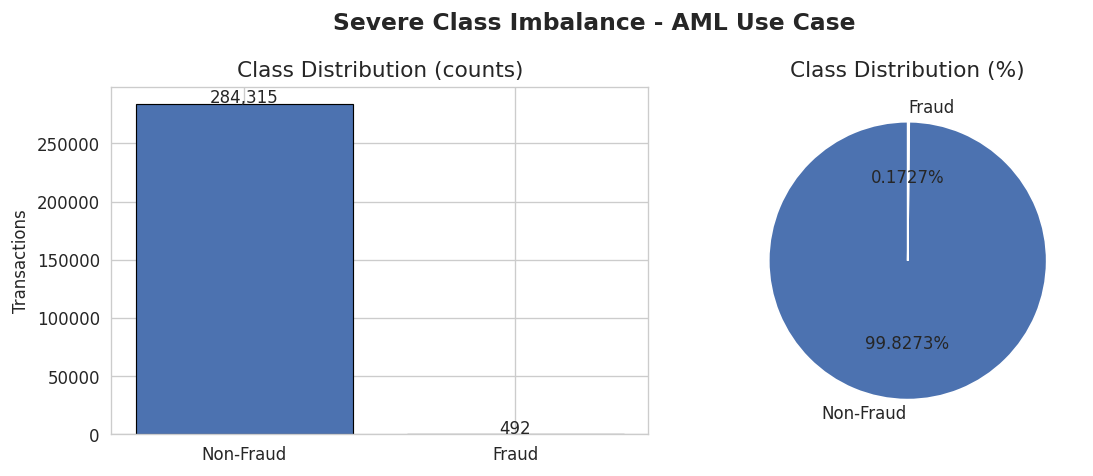

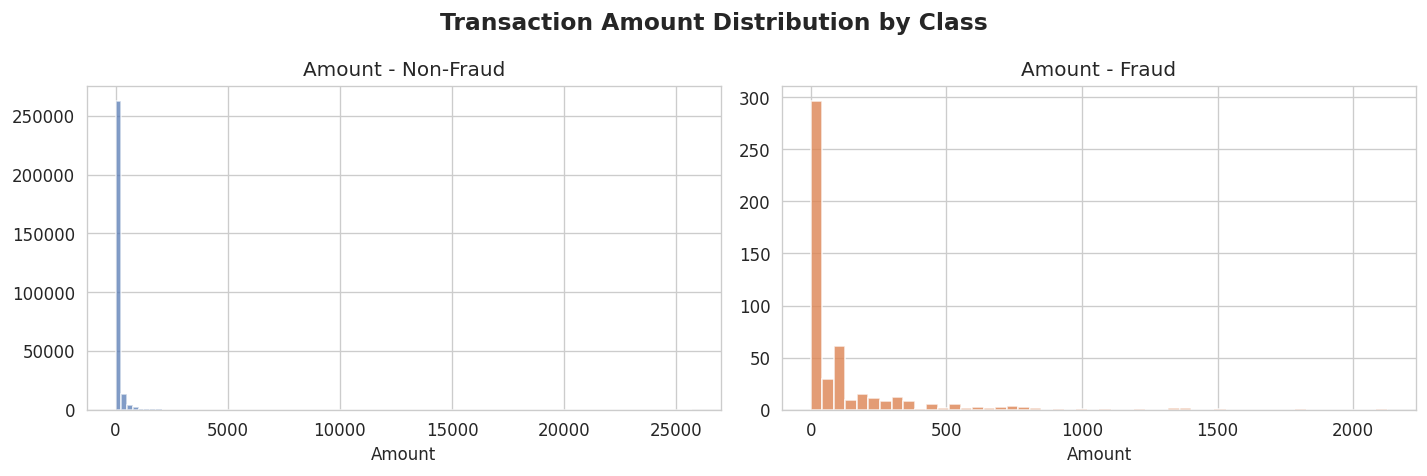

          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


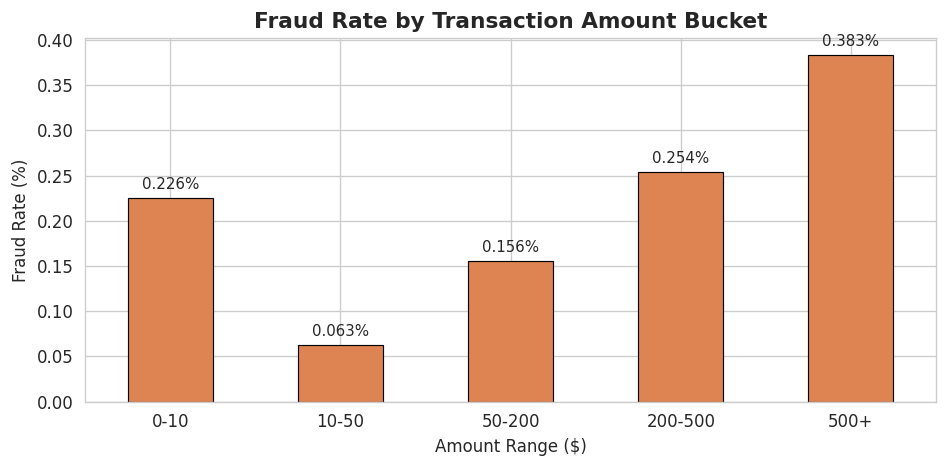

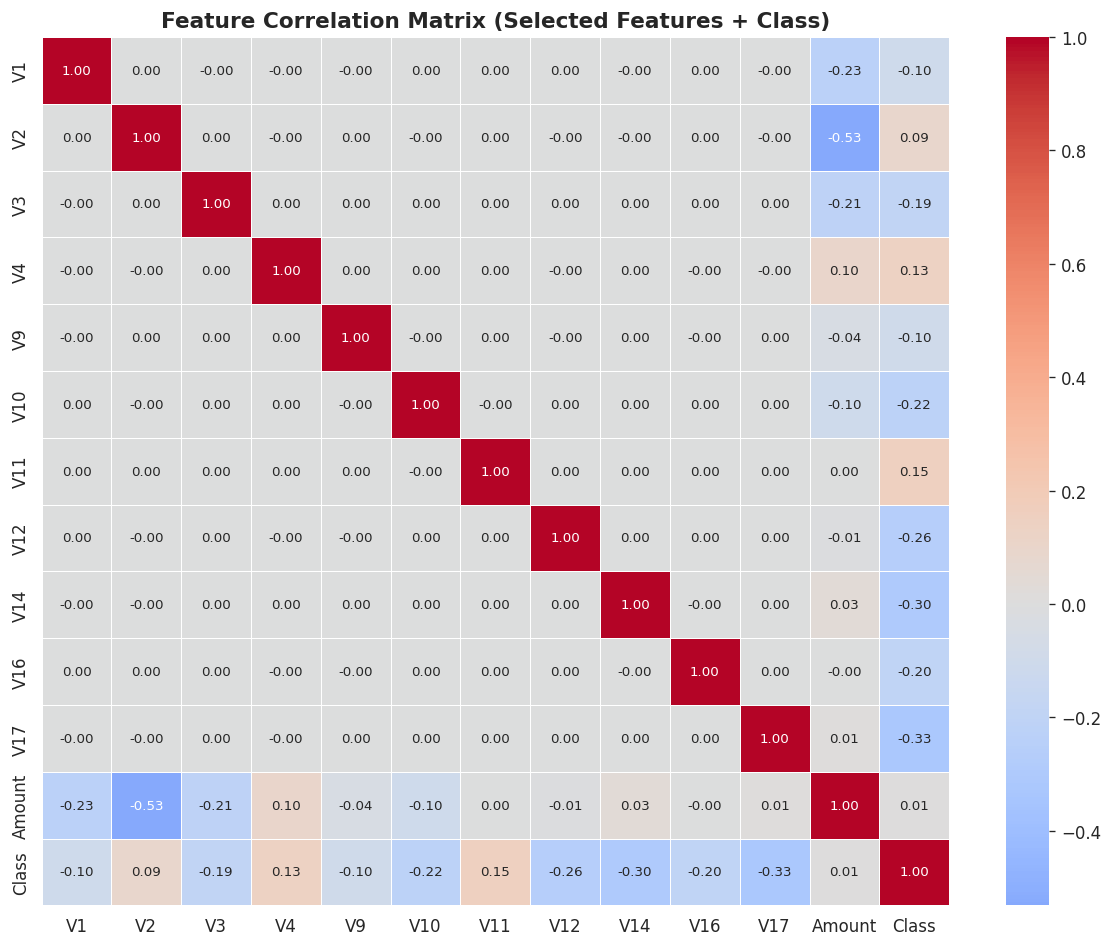

EDA SUMMARY
Total transactions : 284,807
Fraud cases        : 492 (0.1727%)
Imbalance ratio    : 578:1
Median fraud amount: $9.25
Median legit amount: $22.00

Implication: Standard accuracy is misleading under this imbalance.
Cost-sensitive thresholding and HITL evaluation are critical.


In [ ]:
# 01_eda.ipynb - Exploratory Data Analysis
# Dataset: Kaggle Credit Card Fraud Detection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# ── Load Data ──
DATA_PATH = "data/creditcard.csv" if os.path.exists("data/creditcard.csv") else "/content/creditcard.csv"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

# ── Class Imbalance ──
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print(f"\nNon-fraud: {class_counts[0]:,} ({class_pct[0]:.4f}%)")
print(f"Fraud:     {class_counts[1]:,} ({class_pct[1]:.4f}%)")
print(f"Ratio:     {class_counts[0]/class_counts[1]:.0f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Non-Fraud', 'Fraud'], class_counts.values, color=['#4C72B0','#DD8452'], edgecolor='black', linewidth=0.7)
axes[0].set_title('Class Distribution (counts)', fontsize=13)
axes[0].set_ylabel('Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v+500, f'{v:,}', ha='center', fontsize=10)
axes[1].pie(class_counts.values, labels=['Non-Fraud','Fraud'], autopct='%1.4f%%', colors=['#4C72B0','#DD8452'], startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=13)
plt.suptitle('Severe Class Imbalance - AML Use Case', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Amount Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[df['Class']==0]['Amount'], bins=100, color='#4C72B0', alpha=0.7)
axes[0].set_title('Amount - Non-Fraud', fontsize=12)
axes[0].set_xlabel('Amount')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='#DD8452', alpha=0.8)
axes[1].set_title('Amount - Fraud', fontsize=12)
axes[1].set_xlabel('Amount')
plt.suptitle('Transaction Amount Distribution by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig2_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('Class')['Amount'].describe().round(2))

# ── Fraud Rate by Amount Bucket ──
df['Amount_bucket'] = pd.cut(df['Amount'], bins=[0,10,50,200,500,df['Amount'].max()], labels=['0-10','10-50','50-200','200-500','500+'])
fraud_rate = df.groupby('Amount_bucket', observed=True)['Class'].mean() * 100
plt.figure(figsize=(8, 4))
fraud_rate.plot(kind='bar', color='#DD8452', edgecolor='black', linewidth=0.7)
plt.title('Fraud Rate by Transaction Amount Bucket', fontsize=13, fontweight='bold')
plt.xlabel('Amount Range ($)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(fraud_rate):
    plt.text(i, v+0.01, f'{v:.3f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/fig3_fraud_rate_by_amount.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Correlation Heatmap ──
top_features = ['V1','V2','V3','V4','V9','V10','V11','V12','V14','V16','V17','Amount','Class']
corr = df[top_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix (Selected Features + Class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── EDA Summary ──
print("="*55)
print("EDA SUMMARY")
print("="*55)
print(f"Total transactions : {len(df):,}")
print(f"Fraud cases        : {class_counts[1]:,} ({class_pct[1]:.4f}%)")
print(f"Imbalance ratio    : {class_counts[0]/class_counts[1]:.0f}:1")
print(f"Median fraud amount: ${df[df['Class']==1]['Amount'].median():.2f}")
print(f"Median legit amount: ${df[df['Class']==0]['Amount'].median():.2f}")
print("\nImplication: Standard accuracy is misleading under this imbalance.")
print("Cost-sensitive thresholding and HITL evaluation are critical.")